In [1]:
import numpy as np

In [2]:
points = {
    "blue": [[2, 4], [1, 3], [2, 3], [3, 2], [2, 1]],
    'red': [[5, 6], [4, 5], [4, 6], [6, 6], [5, 4]]
}

In [3]:
new_point = [3, 3]

In [4]:
def euc_distance(p, q):
    p, q = np.array(p), np.array(q)
    return np.sqrt(np.sum(np.power(p - q, 2)))

In [9]:
from collections import Counter


class KNN:
    def __init__(self, k=3):
        self.k = k
        self.points = None

    def fit(self, points):
        self.points = points

    def get_neighbors(self, new_point):
        distances = []
        for c in self.points:
            for p in self.points[c]:
                d = euc_distance(p, new_point)
                distances.append([d, c, p])

        return sorted(distances)[:self.k]

    def predict(self, new_point):
        nearest = self.get_neighbors(new_point)
        categories = [n[1] for n in nearest]
        result = Counter(categories).most_common(1)[0][0]
        return result

In [10]:
clf = KNN(k=3)
clf.fit(points)

nearest = clf.get_neighbors(new_point)
neighbors = [n[2] for n in nearest]
print(neighbors)

print(clf.predict(new_point))  # 'blue'

[[2, 3], [3, 2], [2, 4]]
blue


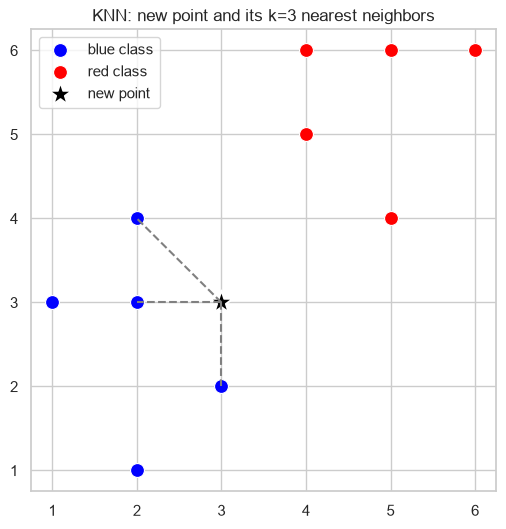

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(6, 6))

for color, pts in points.items():
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    sns.scatterplot(x=xs, y=ys, color=color, s=100, label=f"{color} class", ax=ax)

sns.scatterplot(x=[new_point[0]], y=[new_point[1]], color='black', marker='*', s=300, label='new point', ax=ax)

for n in neighbors:
    ax.plot([new_point[0], n[0]], [new_point[1], n[1]], linestyle='--', color='gray')

ax.set_title('KNN: new point and its k=3 nearest neighbors')
plt.show()